

# MEEP Sources

In **MEEP**, we can simulate sources of electromagnetic energy as point, linear (in 2D), or planar (in 3D) sources. From a temporal perspective, sources can be **harmonic (continuous)** or **pulsed**. For special cases, it is also possible to define sources with a **user-defined time profile**. Sources are additive, meaning we can place any number of them in the simulation area.

We will observe the properties of the sources in an area of 100x100 nodes. The environment initialization and the function for displaying the generated electromagnetic wave are in the file `/utils/mp_src_plot.py`:

```python
import meep as mp
import matplotlib.pyplot as plt
from utils.utils import src_plot

dx = 100
dy = 100
area = mp.Vector3(dx, dy, 0)

def src_plot(dx, dy, data, resolution=1):
    # plotting 2D wave from source and wave cross section at y=50
    ...



## ContinuousSource

The [*ContinuousSource*](https://meep.readthedocs.io/en/latest/Python_User_Interface/#continuoussource) source represents a point-like, continuous, harmonic source of electromagnetic energy with a constant frequency.

In the source's definition, the following properties are specified:
* The **component** of the electromagnetic wave (e.g., $E_z$).
* The **frequency** of the wave.
* The **position** of the source.

In [1]:
# inicializaci a  vystup skriptov v kapitole MEEP Sources

import meep as mp 
import matplotlib.pyplot as plt


dx = 100
dy = 100
area = mp.Vector3(dx, dy, 0)

def src_plot(dx, dy, data, res=1):
    # pomocna funkcia pre zobrazenie zdrojov v MEEP 
    # plotting 2D wave from source and wave cross section at y=50
    fig = plt.figure(figsize=(11,5))
    ax = fig.add_subplot(121)
     
    plt.imshow(data, interpolation='spline36', cmap='bwr', alpha=1.0, 
               extent=(0, dx, 0, dy), norm=plt.Normalize(-0.1, 0.1))
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid()

    ax = fig.add_subplot(122)
    plt.plot(data[50*res,:], label='Y = 50')
    plt.xlabel('X')
    plt.grid()
    plt.legend()
    plt.show()


-----------
Initializing structure...
time for choose_chunkdivision = 0.000100851 s
Working in 2D dimensions.


Computational cell is 100 x 100 x 0 with resolution 2
time for set_epsilon = 0.0230482 s
-----------


FloatProgress(value=0.0, description='0% done ')

run 0 finished at t = 100.0 (400 timesteps)


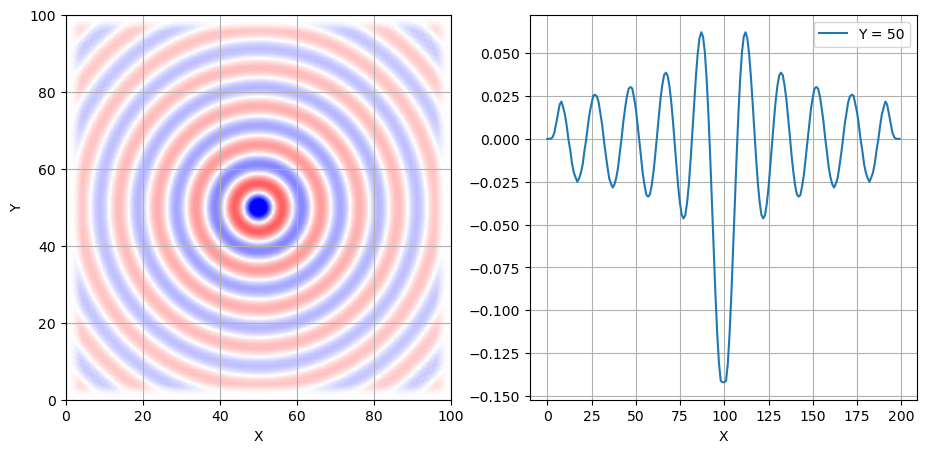

In [2]:
%matplotlib inline


sources = [ mp.Source( mp.ContinuousSource(frequency=0.1), 
                component=mp.Ez, 
                center=mp.Vector3(0,0,0) )]
                     
sim = mp.Simulation(cell_size=area, 
                boundary_layers=[mp.PML(5.0)],
                geometry=[], 
                sources=sources, 
                resolution=2)

sim.run(until=100)

data = sim.get_array(center=mp.Vector3(), 
                size=area, 
                component=mp.Ez)

src_plot(dx, dy, data.transpose(), 2)

<!---  REMOVE -->  
### Animácia časového vývoja

<!-- REMOVE -->
<img src="./img/img_cont_01.gif" >

<!-- REMOVE -->
<img src="./img/img_cont_02.gif" >